# Background

Author: Paul Inkenbrandt
Date: 8/9/2026

Purpose: Compare footprint climatologies produced by the different flux-footprint models
available in `fluxfootprints` — the Kljun et al. xarray rewrite (`ffp_xr`), the classic Kljun
FFP port (`ffp`), the analytical Kormann & Meixner (2001) solution (`km`), a backward
Lagrangian Stochastic model (`ls`), and the Wang et al. (2006) convective model (`wang`) — for
the same station, meteorological inputs, and spatial domain.

This notebook reuses the data-loading and aerodynamic-parameter setup from
[footprint_workflow_example.ipynb](footprint_workflow_example.ipynb), then diverges: instead of
looping over months with a single model, it runs every model over one short comparison window
and lines the results up on a common grid so they can be compared directly.

A few things that make a multi-model comparison harder than a single-model run:

- **Grids don't naturally line up.** `ffp`, `ffp_xr`, and `km` build their grid from
  `np.arange(domain_min, domain_max + dx, dx)`, so they match the requested `DOMAIN`/`DX`/`DY`
  exactly. `ls` bins particles into a histogram and reports **bin centers** (offset by half a
  cell), and `wang` builds its `x` axis outward from `0` before reflecting it, so its extent can
  differ slightly from the requested domain. Every model's output is therefore re-gridded
  (`xarray.DataArray.interp`) onto one common `(x, y)` grid before any comparison is made.
- **Not every model exposes a per-timestep footprint.** `ffp` and `ffp_xr` expose both a
  per-timestep `f_2d` (used by the daily/monthly `summarize_periods` workflow in the other
  notebook) and a time-averaged `fclim_2d`. `km`, `ls`, and `wang` only expose `fclim_2d`. This
  notebook standardizes on `model.get_footprint_climatology()`, which every model implements,
  so the comparison is simply "run each model once on the same short window."
- **`wang` only runs for unstable (convective) conditions** (`ol < 0`) and drops every other row
  internally, and **`ls` is a Monte-Carlo model** whose cost scales with
  `n_particles x n_timesteps`. Both are reasons to keep the comparison window short — this
  notebook uses a handful of midday timesteps from a single day rather than a full month.

# Parameters and Libraries

In [1]:
# parameters to change or review for each run
STATIONID = 'US-UTW'
STATION_LAT  = 39.4452
STATION_LON  = -110.7287

# Comparison window: kept short on purpose (see Background) because the Lagrangian
# Stochastic model is Monte-Carlo (cost ~ n_particles * n_timesteps) and the Wang
# model needs unstable (ol < 0) daytime conditions to have any valid rows at all.
# Widen this once you know how long ls/wang take to run on your own data.
COMPARE_START = "2021-06-15 10:00"
COMPARE_END   = "2021-07-15 14:00"

DX, DY = 10.0, 10.0    # output raster resolution [m]
DOMAIN = (-600.0, 600.0, -600.0, 600.0)

MODEL_TYPES = ["ffp_xr", "ffp", "km", "ls", "wang"]
MODEL_LABELS = {
    "ffp_xr": "FFP (xarray)",
    "ffp":    "FFP (classic)",
    "km":     "Kormann-Meixner",
    "ls":     "Lagrangian Stochastic",
    "wang":   "Wang et al. (2006)",
}
# Okabe-Ito colorblind-safe palette, one fixed color per model (used in every chart below)
MODEL_COLORS = {
    "ffp_xr": "#0072B2",
    "ffp":    "#E69F00",
    "km":     "#009E73",
    "ls":     "#D55E00",
    "wang":   "#56B4E9",
}

REFERENCE_MODEL = "ffp_xr"   # what the difference maps / metrics are measured against

LS_N_PARTICLES = 5000   # reduced from the ls_footprint_adapter default (20000) to keep this demo fast

In [2]:
# path to input, following the same convention as footprint_workflow_example.ipynb
DAT_PATH = f'input_data/{STATIONID}_footprint.parquet'

In [3]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append("../../src")
from fluxfootprints.ffp_daily_monthly_helper import (
    build_climatology,
    compute_aerodynamic_params,
)

## Read in Data and Prepare Aerodynamic Parameters

- Read in eddy covariance data file and create datetime index for start of record
- Compute aerodynamic parameters (z0 and zm), which every model below needs

In [4]:
# read in data and update to datetime_start index
df_all = pd.read_parquet(DAT_PATH)
df_all = df_all.sort_index()

# compute z0 and zm (needed by every model below)
df_all = compute_aerodynamic_params(
    df_all,
    inst_height='measurement_height',
    crop_height='crop_height_m',
    veg_type='alfalfa',
)

In [5]:
print(df_all.first_valid_index(), df_all.last_valid_index())

2021-06-01 00:00:00 2021-12-31 23:30:00


## Select a Comparison Window

Subset to `COMPARE_START`–`COMPARE_END` and drop rows missing any field required across the
five models. `wang` additionally needs some of those rows to be unstable (`mo_length_1_1_1 <
0`); the count is reported below so a failure further down is easy to diagnose.

In [6]:
# superset of columns needed across ffp / ffp_xr / km / ls / wang
REQ_FIELDS = ["mo_length_1_1_1", "v_sigma_1_1_1", "ustar_1_1_1", "wd_1_1_1", "ws_1_1_1", "zm", "z0"]

df_window = df_all.loc[COMPARE_START:COMPARE_END].copy()
df_window = df_window.dropna(subset=REQ_FIELDS)

n_unstable = int((df_window["mo_length_1_1_1"] < 0).sum())
print(f"Comparison window {COMPARE_START} -> {COMPARE_END}: {len(df_window)} valid timesteps "
      f"({n_unstable} unstable/convective, required by the wang model)")

assert len(df_window) > 0, "No valid timesteps in the comparison window - widen COMPARE_START/COMPARE_END"
df_window[REQ_FIELDS]

Comparison window 2021-06-15 10:00 -> 2021-07-15 14:00: 496 valid timesteps (161 unstable/convective, required by the wang model)


,mo_length_1_1_1,v_sigma_1_1_1,ustar_1_1_1,wd_1_1_1,ws_1_1_1,zm,z0
datetime_start,,,,,,,
2021-07-05 06:30:00,16.47745,0.507604,0.222971,317.8547,3.111619,2.8923,0.03813
2021-07-05 07:00:00,76.45846,0.845518,0.384803,304.4949,4.991240,2.8923,0.03813
2021-07-05 07:30:00,67.52245,0.896419,0.372255,306.0229,5.067852,2.8923,0.03813
2021-07-05 08:00:00,73.47021,1.156355,0.461377,282.6653,6.251216,2.8923,0.03813
2021-07-05 08:30:00,40.42930,1.193933,0.341524,284.8635,5.399969,2.8923,0.03813
...,...,...,...,...,...,...,...
2021-07-15 12:00:00,-41.76294,1.342096,0.320913,196.9893,2.203942,2.8253,0.05043
2021-07-15 12:30:00,-24.65554,0.919386,0.261739,222.2221,1.442072,2.8253,0.05043
2021-07-15 13:00:00,-43.22299,0.827825,0.219982,180.3062,1.789526,2.8253,0.05043


## Run Every Footprint Model

Same `build_climatology` call as the main workflow notebook, just looped over
`MODEL_TYPES` with the same column mapping and domain for every model. Failures (e.g. `wang`
finding no unstable rows in the window) are caught and reported rather than stopping the
notebook, so the comparison below just uses whichever models succeeded.

In [7]:
models = {}     # model_type -> fitted model instance
run_info = []   # per-model bookkeeping for the summary table

for model_type in MODEL_TYPES:
    label = MODEL_LABELS[model_type]
    print(f"Running {label} ({model_type}) ... ", end="", flush=True)

    model_kwargs = {"n_particles": LS_N_PARTICLES} if model_type == "ls" else {}

    t0 = time.perf_counter()
    try:
        model = build_climatology(
            df_window,
            model_type=model_type,
            ustar='ustar_1_1_1',
            ol='mo_length_1_1_1',
            umean='ws_1_1_1',
            sigmav='v_sigma_1_1_1',
            wind_dir='wd_1_1_1',
            zm='zm',
            z0='z0',
            h=2000.0,
            dx=DX,
            dy=DY,
            domain=DOMAIN,
            verbosity=0,   # quiet: default verbosity=2 logs every timestep, noisy across 5 models
            **model_kwargs,
        )
        runtime_s = time.perf_counter() - t0

        n_used = getattr(model, "ts_len", None)
        if n_used is None:
            n_used = model.results.attrs.get("n_timesteps", len(model.df))

        models[model_type] = model
        run_info.append({"model": model_type, "label": label, "status": "ok",
                          "n_timesteps": n_used, "runtime_s": runtime_s})
        print(f"done ({n_used} timesteps, {runtime_s:.1f}s)")

    except Exception as exc:
        runtime_s = time.perf_counter() - t0
        run_info.append({"model": model_type, "label": label, "status": f"failed: {exc}",
                          "n_timesteps": 0, "runtime_s": runtime_s})
        print(f"FAILED: {exc}")

run_df = pd.DataFrame(run_info)
run_df

Running FFP (xarray) (ffp_xr) ... 

131/496 timesteps excluded due to range bounds or missing both z0 and umean.


done (365 timesteps, 1.3s)
Running FFP (classic) (ffp) ... done (365 timesteps, 1.5s)
Running Kormann-Meixner (km) ... done (496 timesteps, 130.8s)
Running Lagrangian Stochastic (ls) ... done (496 timesteps, 637.9s)
Running Wang et al. (2006) (wang) ... done (161 timesteps, 0.0s)


,model,label,status,n_timesteps,runtime_s
0,ffp_xr,FFP (xarray),ok,365,1.259231
1,ffp,FFP (classic),ok,365,1.487458
2,km,Kormann-Meixner,ok,496,130.835229
3,ls,Lagrangian Stochastic,ok,496,637.911606
4,wang,Wang et al. (2006),ok,161,0.035872


## Regrid Every Model onto a Common Grid

Every model exposes `get_footprint_climatology()` (dims `x`, `y`), but on its own native
grid (see Background). `xarray.interp` puts each one onto the same `common_x`/`common_y` grid
built from `DOMAIN`/`DX`/`DY`; models whose native grid already matches that (`ffp`, `ffp_xr`,
`km`) pass through essentially unchanged. Interpolating outside a model's native extent fills
with 0, which can shave a little mass off the total — mainly for `ls` and `wang` — so each
raster is renormalized to integrate to 1 over the common grid afterward. Treat *shape* and
*peak-location* differences as the meaningful signal here; absolute density right at the domain
edges is the part most affected by this step.

In [8]:
common_x = np.arange(DOMAIN[0], DOMAIN[1] + DX, DX)
common_y = np.arange(DOMAIN[2], DOMAIN[3] + DY, DY)
cell_area = DX * DY

rasters = {}   # model_type -> 2D numpy array (nx, ny) on the common grid, sum*cell_area == 1

for model_type, model in models.items():
    fclim = model.get_footprint_climatology().transpose("x", "y")   # native grid
    regridded = fclim.interp(x=common_x, y=common_y, method="linear",
                              kwargs={"fill_value": 0.0}).fillna(0.0)

    arr = np.clip(regridded.values, 0.0, None)   # interpolation can create tiny negative ripples
    total = arr.sum() * cell_area
    if total > 0:
        arr = arr / total
    rasters[model_type] = arr

print(f"Common grid: {len(common_x)} x {len(common_y)} cells at {DX}m x {DY}m")

Common grid: 121 x 121 cells at 10.0m x 10.0m


## Side-by-Side Footprint Maps

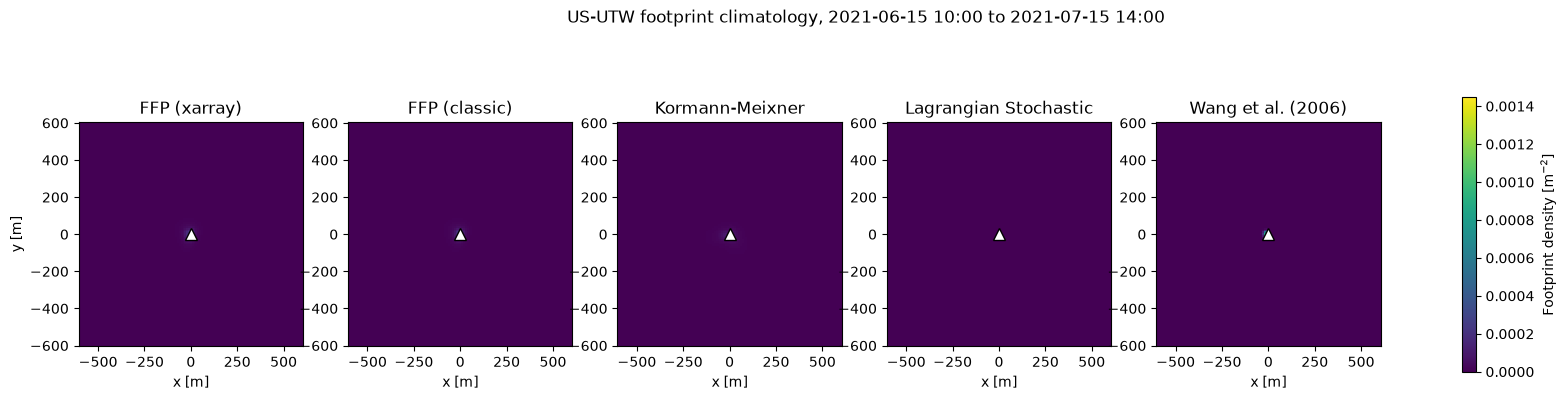

In [9]:
vmax = max(arr.max() for arr in rasters.values())

fig, axes = plt.subplots(1, len(rasters), figsize=(4.2 * len(rasters), 4.2), squeeze=False)
axes = axes[0]

for ax, model_type in zip(axes, rasters):
    im = ax.pcolormesh(common_x, common_y, rasters[model_type].T, cmap="viridis",
                        vmin=0, vmax=vmax, shading="auto")
    ax.plot(0, 0, marker="^", color="white", markeredgecolor="black", markersize=9, zorder=5)
    ax.set_title(MODEL_LABELS[model_type])
    ax.set_xlabel("x [m]")
    ax.set_aspect("equal")

axes[0].set_ylabel("y [m]")
fig.colorbar(im, ax=axes.tolist(), shrink=0.85, label="Footprint density [m$^{-2}$]")
fig.suptitle(f"{STATIONID} footprint climatology, {COMPARE_START} to {COMPARE_END}", y=1.03)
plt.show()

## Difference Maps Relative to the Reference Model

`REFERENCE_MODEL` (set above, default `ffp_xr`) is subtracted from every other model's
raster. Red = that model predicts *more* source contribution than the reference at that cell;
blue = *less*.

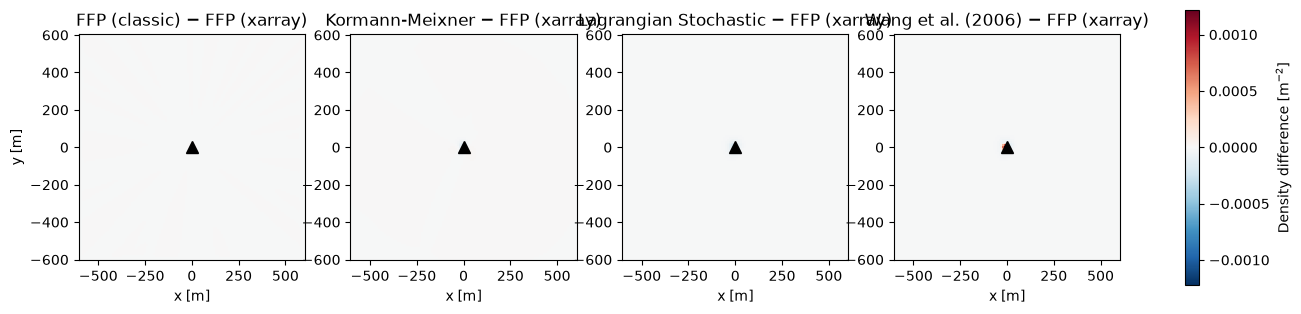

In [10]:
ref_arr = rasters[REFERENCE_MODEL]
other_types = [m for m in rasters if m != REFERENCE_MODEL]

diffs = {m: rasters[m] - ref_arr for m in other_types}
dmax = max(np.abs(d).max() for d in diffs.values())

fig, axes = plt.subplots(1, len(other_types), figsize=(4.2 * len(other_types), 4.2), squeeze=False)
axes = axes[0]

for ax, model_type in zip(axes, other_types):
    im = ax.pcolormesh(common_x, common_y, diffs[model_type].T, cmap="RdBu_r",
                        vmin=-dmax, vmax=dmax, shading="auto")
    ax.plot(0, 0, marker="^", color="black", markersize=9, zorder=5)
    ax.set_title(f"{MODEL_LABELS[model_type]} − {MODEL_LABELS[REFERENCE_MODEL]}")
    ax.set_xlabel("x [m]")
    ax.set_aspect("equal")

axes[0].set_ylabel("y [m]")
fig.colorbar(im, ax=axes.tolist(), shrink=0.85, label="Density difference [m$^{-2}$]")
plt.show()

## Quantitative Comparison Metrics

For each model, relative to `REFERENCE_MODEL`:

- **RMSE_vs_ref** — cell-by-cell root-mean-square difference in footprint density.
- **peak_dist_m** / **peak_diff_vs_ref_m** — distance from the tower to the model's peak
  contribution cell, and how far that is from the reference model's peak.
- **overlap80_vs_ref_pct** — percent overlap between the two models' 80% source-area cells.
- **source_area_80_ha** — size of the model's own 80% source area, in hectares.
- **runtime_s** — wall-clock time for `build_climatology` on this comparison window.

In [11]:
def peak_distance(arr, x, y):
    """Distance from the tower (0, 0) to the cell of maximum footprint density."""
    ix, iy = np.unravel_index(np.argmax(arr), arr.shape)
    return float(np.hypot(x[ix], y[iy]))

def mask_80(arr):
    """Boolean mask of the smallest set of cells containing 80% of the footprint."""
    flat = arr.flatten()
    order = np.argsort(flat)[::-1]
    cumsum = np.cumsum(flat[order]) * cell_area
    n80 = np.searchsorted(cumsum, 0.8)
    thresh = flat[order][min(n80, flat.size - 1)]
    return arr >= thresh

def source_area_80_ha(arr):
    return mask_80(arr).sum() * cell_area / 10_000.0

ref_mask80 = mask_80(ref_arr)
peak_ref = peak_distance(ref_arr, common_x, common_y)

metrics = []
for model_type, arr in rasters.items():
    peak = peak_distance(arr, common_x, common_y)
    overlap = float((mask_80(arr) & ref_mask80).sum() / ref_mask80.sum() * 100.0)
    runtime_s = run_df.loc[run_df["model"] == model_type, "runtime_s"].iloc[0]

    metrics.append({
        "model": MODEL_LABELS[model_type],
        "RMSE_vs_ref": float(np.sqrt(np.mean((arr - ref_arr) ** 2))),
        "peak_dist_m": peak,
        "peak_diff_vs_ref_m": abs(peak - peak_ref),
        "overlap80_vs_ref_pct": overlap,
        "source_area_80_ha": source_area_80_ha(arr),
        "runtime_s": runtime_s,
    })

metrics_df = pd.DataFrame(metrics).set_index("model")
metrics_df.round(3)

,RMSE_vs_ref,peak_dist_m,peak_diff_vs_ref_m,overlap80_vs_ref_pct,source_area_80_ha,runtime_s
model,,,,,,
FFP (xarray),0.0,10.000,0.000,100.000,2.23,1.259
FFP (classic),0.0,10.000,0.000,99.103,2.21,1.487
Kormann-Meixner,0.0,22.361,12.361,100.000,10.29,130.835
Lagrangian Stochastic,0.0,848.528,838.528,100.000,146.41,637.912
Wang et al. (2006),0.0,10.000,0.000,4.484,0.10,0.036


## Visual Summary of Metrics

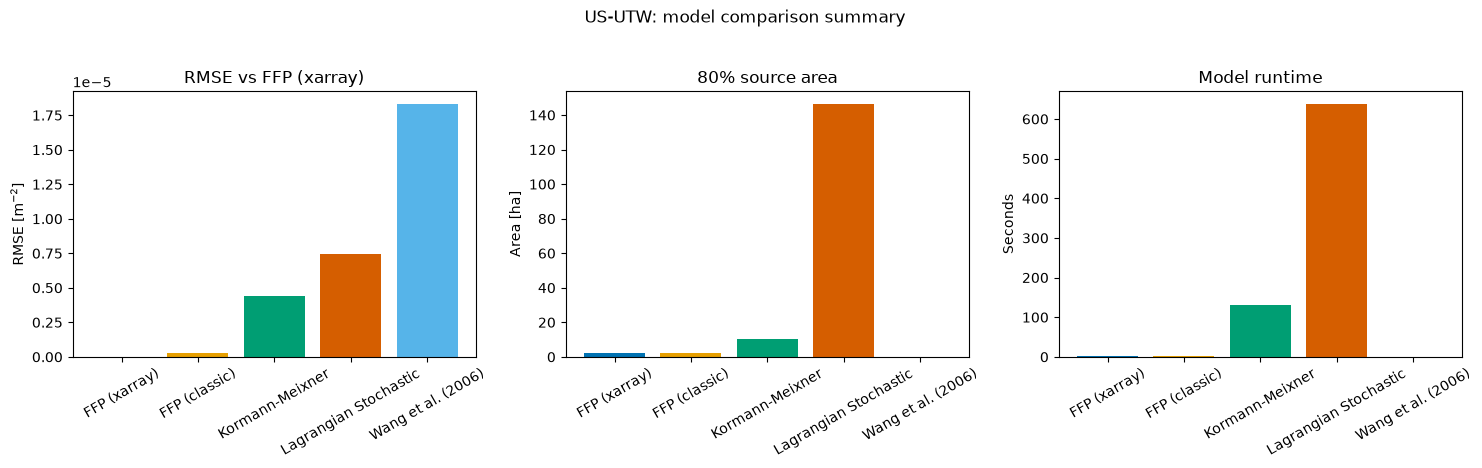

In [12]:
plot_order = list(rasters.keys())
x_labels = [MODEL_LABELS[m] for m in plot_order]
bar_colors = [MODEL_COLORS[m] for m in plot_order]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].bar(x_labels, metrics_df.loc[x_labels, "RMSE_vs_ref"], color=bar_colors)
axes[0].set_title(f"RMSE vs {MODEL_LABELS[REFERENCE_MODEL]}")
axes[0].set_ylabel("RMSE [m$^{-2}$]")

axes[1].bar(x_labels, metrics_df.loc[x_labels, "source_area_80_ha"], color=bar_colors)
axes[1].set_title("80% source area")
axes[1].set_ylabel("Area [ha]")

axes[2].bar(x_labels, metrics_df.loc[x_labels, "runtime_s"], color=bar_colors)
axes[2].set_title("Model runtime")
axes[2].set_ylabel("Seconds")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

fig.suptitle(f"{STATIONID}: model comparison summary", y=1.03)
fig.tight_layout()
plt.show()

## Notes & Caveats

- **The comparison window is intentionally short.** Widen `COMPARE_START`/`COMPARE_END` for a
  more representative comparison, but check `ls` and `wang` runtimes in `run_df` first — `ls`
  cost scales with `n_particles x n_timesteps`.
- **Regridding + renormalizing changes absolute densities**, most for `ls` and `wang` whose
  native grids don't match `DOMAIN` exactly. Shape and peak-location differences are more
  trustworthy than small density differences near the domain edges.
- **`wang` silently uses fewer rows than the other models** — it drops every timestep with
  `ol >= 0` (stable/neutral) before running. If it's missing from `run_df` entirely, the window
  had no unstable rows at all.
- **`ls` is stochastic.** Its raster will change slightly between runs; increase
  `LS_N_PARTICLES` (at the cost of runtime) if it looks noisy relative to the other models.
- **Metrics are all relative to `REFERENCE_MODEL`.** Change it at the top of the notebook and
  rerun from "Regrid Every Model onto a Common Grid" onward to compare against a different
  baseline.
- **This notebook does not export GeoTIFFs.** For that, use the daily/monthly
  `summarize_periods` + `export_rasters_geotiff` workflow from
  [footprint_workflow_example.ipynb](footprint_workflow_example.ipynb) (works for `ffp`/`ffp_xr`,
  which expose a per-timestep footprint), or call `model.to_netcdf(path)` on any individual
  model here to save its own climatology.